# RFSV Volatility Predictor

Based on Gatheral et al. (2014) "Volatility is Rough". Implements log-variance conditional expectation prediction via Riemann sum discretization, with AR/HAR benchmarks.

## 1. Imports and Data Loading

In [1]:
import sys
sys.path.append('../models_en')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from HurstEstimator import HurstEstimator
from RFSVPredictor import (
    RFSVPredictor,
    predict_ar,
    predict_har,
    compute_p_ratio,
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = ['Arial Unicode MS']

In [2]:
# Load variance proxy data
df = pd.read_csv('../data/variance_proxy_20230101_20251231.csv')
# df = pd.read_csv('../data/variance_proxy_20220701_20231231.csv')  # poor results

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

# log σ² series (prediction uses log-variance)
log_var = np.log(df['rv_uz'])
var_series = df['rv_uz']

print(f"Data range: {df.index[0].date()} ~ {df.index[-1].date()}")
print(f"Trading days: {len(df)}")

Data range: 2023-01-03 ~ 2025-12-31
Trading days: 727


## 2. Parameter Estimation: H and ν² (Single Regression)

- Use `HurstEstimator` for q=2 variogram regression on `log(σ)=0.5*log(rv_uz)`
- One regression yields: `H = slope / 2`, `ν² = exp(intercept)`
- Avoid duplicate estimation via `RFSVPredictor.estimate_nu_sq`

In [3]:
# Estimate Hurst H (input: log σ = 0.5*log(rv_uz))
hurst = HurstEstimator()
log_vol_series = 0.5 * np.log(df['rv_uz'])   # log(σ)

START_IDX = 500  # Use first 500 values for parameter estimation
H, h_info = hurst.estimate_hurst_variogram(log_vol_series[:START_IDX], q=2.0)  
print(f"Hurst H = {H:.4f} (R² = {h_info['r_squared']:.4f})")
print(f"2nd moment intercept {h_info['intercept']:.4f}, ν² = {np.exp(h_info['intercept'])}")

nu_sq = np.exp(h_info['intercept'])

Hurst H = 0.0979 (R² = 0.9125)
2nd moment intercept -3.1368, ν² = 0.0434213463736186


## 3. RFSV Rolling Prediction

Predict for Δ = 1, 5, 20 days. 500-day warm-up matches the paper.

In [4]:
deltas = [1, 5, 20]
rfsv_preds = {}

for delta in deltas:
    predictor = RFSVPredictor(H=H, nu_sq=nu_sq, delta=delta, window_ratio=3)
    preds = predictor.predict_rolling(log_var.values, start_idx=START_IDX)
    rfsv_preds[delta] = preds
    print(f"Δ={delta}: {len(preds)} predictions")

Δ=1: 226 predictions
Δ=5: 222 predictions
Δ=20: 207 predictions


In [5]:
# # Test forecast performance for different window_ratio across deltas
# START_IDX = 500
# deltas = [1, 5, 20]
# window_ratios = np.linspace(0.1, 3, 20)  # Test window coefficients
# mean_log_var = np.nanmean(log_var.values)

# results_wr = []  # (delta, window_ratio, P)
# rfsv_preds = {}  # Best window_ratio predictions for comparison

# for delta in deltas:
#     best_p, best_wr, best_preds = np.inf, None, None
#     for wr in window_ratios:
#         predictor = RFSVPredictor(H=H, nu_sq=nu_sq, delta=delta, window_ratio=wr)
#         preds = predictor.predict_rolling(log_var.values, start_idx=START_IDX)
#         actual = log_var.values[START_IDX + delta :]
#         p = compute_p_ratio(actual, preds, mean_log_var)
#         results_wr.append({'Δ': delta, 'window_ratio': wr, 'P': p})
#         if p < best_p:
#             best_p, best_wr, best_preds = p, wr, preds
#     rfsv_preds[delta] = best_preds
#     print(f"Δ={delta}: best window_ratio={best_wr:.2f}, P={best_p:.4f}")

# df_wr = pd.DataFrame(results_wr)
# pivot_wr = df_wr.pivot(index='Δ', columns='window_ratio', values='P')
# print("\nP vs window_ratio (row=Δ, col=window_ratio):")
# print(pivot_wr.round(3).to_string())

In [6]:
# # Visualization: P vs window_ratio for each Δ
# fig, ax = plt.subplots(figsize=(8, 5))
# for delta in deltas:
#     sub = df_wr[df_wr['Δ'] == delta]
#     ax.plot(sub['window_ratio'], sub['P'], 'o-', label=f'Δ={delta}')
# ax.axhline(1, color='gray', linestyle='--', alpha=0.7)
# ax.set_xlabel('window_ratio (r)')
# ax.set_ylabel('P (MSE ratio)')
# ax.set_title('RFSV P vs window_ratio')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

## 4. AR and HAR Benchmarks

- **AR(5), AR(10)**: Rolling 500-day coefficient estimation
- **HAR(3)**: 1-day, 5-day, 20-day means as regressors

In [7]:
# AR and HAR prediction
ar5_preds = {}
ar10_preds = {}
har_preds = {}

for delta in deltas:
    ar5_preds[delta] = predict_ar(log_var.values, delta=delta, p=5, train_window=START_IDX)
    ar10_preds[delta] = predict_ar(log_var.values, delta=delta, p=10, train_window=START_IDX)
    har_preds[delta] = predict_har(log_var.values, delta=delta, train_window=START_IDX)

## 5. Evaluation Metric P (MSE Ratio)

### Meaning of P

P is the metric in Gatheral (2014) for comparing volatility forecast performance:

$$P = \frac{\sum_k \big(\log\sigma^2_{k+\Delta} - \widehat{\log\sigma^2}_{k+\Delta}\big)^2}{\sum_k \big(\log\sigma^2_{k+\Delta} - \overline{\log\sigma^2}\big)^2}$$

i.e. **forecast MSE** over **variance of actual around sample mean**.

- **P < 1**: Forecast beats naive (sample mean); smaller P = better
- **P = 1**: Same as naive
- **P > 1**: Worse than naive

Models can be compared by P at the same Δ; smaller P = better.

In [8]:
# Aligned actual: log σ²_{k+Δ}, k from START_IDX to n-delta-1
mean_log_var = np.nanmean(log_var.values)

results = []
for delta in deltas:
    n = len(log_var)
    actual = log_var.values[START_IDX + delta : n]
    # Prediction length = n - START_IDX - delta
    p_rfsv = compute_p_ratio(actual, rfsv_preds[delta], mean_log_var)
    p_ar5 = compute_p_ratio(actual, ar5_preds[delta], mean_log_var)
    p_ar10 = compute_p_ratio(actual, ar10_preds[delta], mean_log_var)
    p_har = compute_p_ratio(actual, har_preds[delta], mean_log_var)
    results.append({
        'Δ': delta,
        'AR(5)': p_ar5,
        'AR(10)': p_ar10,
        'HAR(3)': p_har,
        'RFSV': p_rfsv,
    })

df_results = pd.DataFrame(results).set_index('Δ')
print("Table 5.1 style - log-variance forecast P (CSI 300)")
print(df_results.round(3).to_string())

Table 5.1 style - log-variance forecast P (CSI 300)
    AR(5)  AR(10)  HAR(3)   RFSV
Δ                               
1   0.506   0.505   0.502  0.604
5   0.801   0.794   0.783  0.880
20  1.005   1.022   1.017  1.354


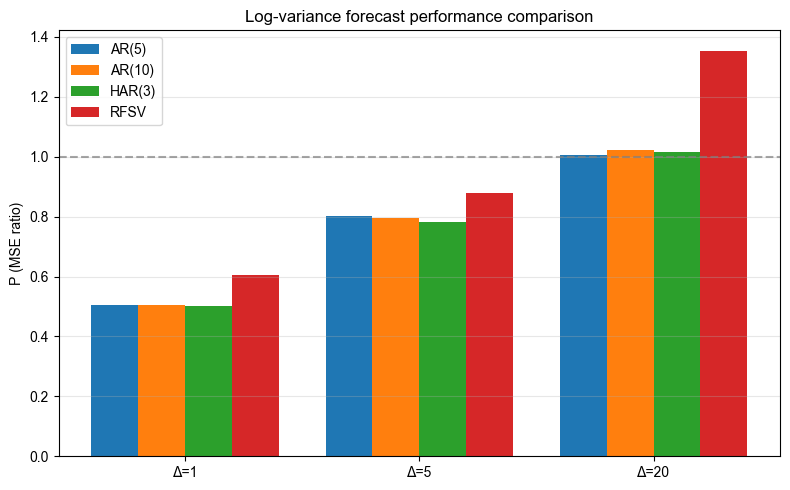

In [9]:
# Visualization: P comparison across models
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(deltas))
width = 0.2

ax.bar(x - 1.5*width, df_results['AR(5)'], width, label='AR(5)')
ax.bar(x - 0.5*width, df_results['AR(10)'], width, label='AR(10)')
ax.bar(x + 0.5*width, df_results['HAR(3)'], width, label='HAR(3)')
ax.bar(x + 1.5*width, df_results['RFSV'], width, label='RFSV')
ax.axhline(1, color='gray', linestyle='--', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f'Δ={d}' for d in deltas])
ax.set_ylabel('P (MSE ratio)')
ax.set_title('Log-variance forecast performance comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Forecast path vs actual volatility

Compare forecast volatility paths with realized volatility time series.

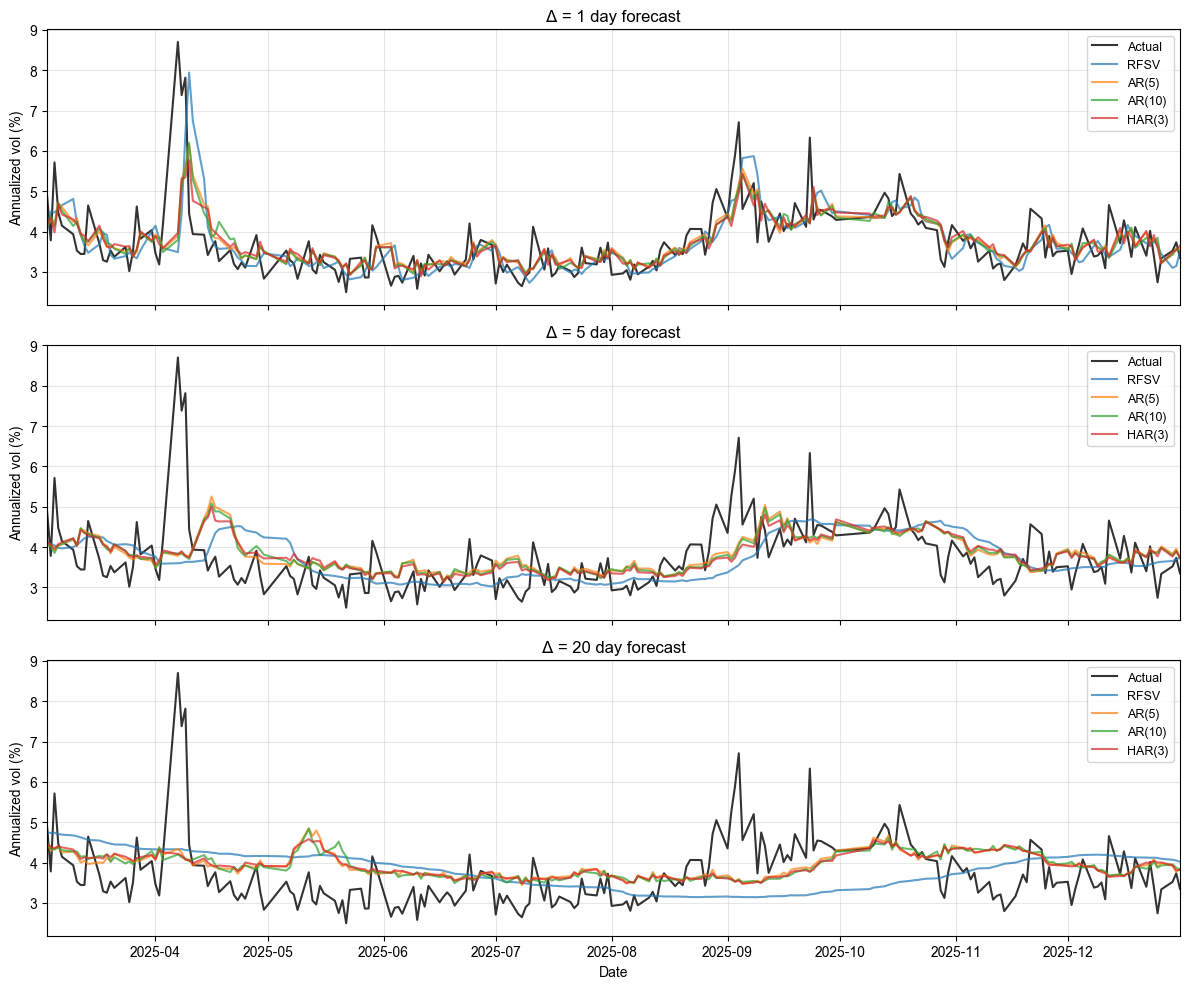

In [10]:
# Volatility forecast path vs actual (annualized vol %)
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
n = len(log_var)

for idx, delta in enumerate(deltas):
    ax = axes[idx]
    dates = df.index[START_IDX + delta : n]
    # Actual annualized vol
    actual_vol = np.sqrt(np.exp(log_var.values[START_IDX + delta : n]) * 252) * 100
    ax.plot(dates, actual_vol, 'k-', alpha=0.8, linewidth=1.5, label='Actual')
    # Model forecasts (log to annualized vol)
    rfsv_vol = np.sqrt(np.exp(rfsv_preds[delta]) * 252) * 100
    ar5_vol = np.sqrt(np.exp(ar5_preds[delta]) * 252) * 100
    ar10_vol = np.sqrt(np.exp(ar10_preds[delta]) * 252) * 100
    har_vol = np.sqrt(np.exp(har_preds[delta]) * 252) * 100
    ax.plot(dates, rfsv_vol, alpha=0.7, label='RFSV')
    ax.plot(dates, ar5_vol, alpha=0.7, label='AR(5)')
    ax.plot(dates, ar10_vol, alpha=0.7, label='AR(10)')
    ax.plot(dates, har_vol, alpha=0.7, label='HAR(3)')
    ax.set_ylabel('Annualized vol (%)')
    ax.set_title(f'Δ = {delta} day forecast')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(dates[0], dates[-1])

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

## 6. Variance Forecast (Eq. 5.2)

σ̂² = exp{ log σ̂² + 2cν²Δ^{2H} }. Compare with AR/HAR in variance space.

In [11]:
# Variance forecast: RFSV uses correction formula; AR/HAR take exp of log forecast
def compute_p_ratio_var(actual_var, pred_var, mean_var):
    """P ratio in variance space"""
    mask = ~(np.isnan(actual_var) | np.isnan(pred_var) | (actual_var <= 0) | (pred_var <= 0))
    if mask.sum() < 2:
        return np.nan
    a, p = actual_var[mask], pred_var[mask]
    mse = np.mean((a - p) ** 2)
    var_term = np.mean((a - mean_var) ** 2)
    return mse / var_term if var_term > 1e-12 else np.nan

mean_var = np.nanmean(var_series.values)
results_var = []

for delta in deltas:
    n = len(var_series)
    actual_v = var_series.values[START_IDX + delta : n]
    
    # RFSV variance forecast
    predictor = RFSVPredictor(H=H, nu_sq=nu_sq, delta=delta, window_ratio=1.0)
    rfsv_var_preds = []
    for t in range(START_IDX, n - delta):
        rfsv_var_preds.append(predictor.predict_variance(var_series.values, t))
    rfsv_var_preds = np.array(rfsv_var_preds)
    
    # AR/HAR forecast in log space, exp gives variance
    ar5_var = np.exp(ar5_preds[delta])
    ar10_var = np.exp(ar10_preds[delta])
    har_var = np.exp(har_preds[delta])
    
    results_var.append({
        'Δ': delta,
        'AR(5)': compute_p_ratio_var(actual_v, ar5_var, mean_var),
        'AR(10)': compute_p_ratio_var(actual_v, ar10_var, mean_var),
        'HAR(3)': compute_p_ratio_var(actual_v, har_var, mean_var),
        'RFSV': compute_p_ratio_var(actual_v, rfsv_var_preds, mean_var),
    })

df_results_var = pd.DataFrame(results_var).set_index('Δ')
print("Table 5.2 style - variance forecast P (CSI 300)")
print(df_results_var.round(3).to_string())

Table 5.2 style - variance forecast P (CSI 300)
    AR(5)  AR(10)  HAR(3)   RFSV
Δ                               
1   0.601   0.609   0.601  0.753
5   0.858   0.851   0.844  1.108
20  0.893   0.911   0.905  1.128


### Diagnosing why RFSV underperforms benchmarks

From the forecast path visualization, RFSV captures large volatility moves but with lag. Yet RFSV has worse P than AR/HAR. This section diagnoses via multiple metrics.

**Hypotheses to test:**
- **Lag effect**: RFSV forecasts lag by k days, causing large errors at volatility jumps
- **High-vol regime**: RFSV errors larger in high-vol periods; AR/HAR more robust
- **Error structure**: RFSV errors correlate with vol level; MSE penalizes large errors, raising P

In [12]:
# Diagnostic metrics
from scipy.stats import skew, kurtosis

print("=" * 70)
print("Diagnostic 1: Lag test - RFSV P after shifting forecast by k days")
print("=" * 70)
lag_results = []
for delta in deltas:
    n = len(log_var)
    actual = log_var.values[START_IDX + delta : n]
    for k in range(4):
        if k == 0:
            p_lag = compute_p_ratio(actual, rfsv_preds[delta], mean_log_var)
        else:
            # Shift forecast by k: drop first k of pred, last k of actual
            rfsv_shifted = rfsv_preds[delta][k:]
            actual_shifted = actual[:-k]
            p_lag = compute_p_ratio(actual_shifted, rfsv_shifted, mean_log_var)
        lag_results.append({'Δ': delta, 'lag_k': k, 'P(k)': p_lag})

df_lag = pd.DataFrame(lag_results)
lag_pivot = df_lag.pivot(index='Δ', columns='lag_k', values='P(k)')
lag_pivot.columns = [f'k={int(c)}' for c in lag_pivot.columns]
print(lag_pivot.round(3).to_string())
print()

print("=" * 70)
print("Diagnostic 2: High/low vol regime split (80th percentile of actual)")
print("=" * 70)
regime_results = []
for delta in deltas:
    n = len(log_var)
    actual = log_var.values[START_IDX + delta : n]
    threshold = np.percentile(actual, 80)
    high_mask = actual >= threshold
    low_mask = ~high_mask
    
    for model, preds in [('RFSV', rfsv_preds[delta]), 
                          ('AR(5)', ar5_preds[delta]), 
                          ('HAR(3)', har_preds[delta])]:
        mask_valid = ~(np.isnan(actual) | np.isnan(preds))
        high_valid = high_mask & mask_valid
        low_valid = low_mask & mask_valid
        
        mse_high = np.mean((actual[high_valid] - preds[high_valid])**2) if high_valid.sum() > 0 else np.nan
        mse_low = np.mean((actual[low_valid] - preds[low_valid])**2) if low_valid.sum() > 0 else np.nan
        
        regime_results.append({
            'Δ': delta, 'Model': model, 
            'MSE_high_vol': mse_high, 'n_high': high_valid.sum(),
            'MSE_low_vol': mse_low, 'n_low': low_valid.sum()
        })

df_regime = pd.DataFrame(regime_results)
for delta in deltas:
    print(f"\nΔ = {delta} days:")
    subset = df_regime[df_regime['Δ'] == delta][['Model', 'MSE_high_vol', 'n_high', 'MSE_low_vol', 'n_low']]
    print(subset.round(4).to_string(index=False))

print("\n" + "=" * 70)
print("Diagnostic 3: Correlation of error with vol level (error = actual - pred)")
print("=" * 70)
corr_results = []
for delta in deltas:
    n = len(log_var)
    actual = log_var.values[START_IDX + delta : n]
    for model, preds in [('RFSV', rfsv_preds[delta]), 
                          ('AR(5)', ar5_preds[delta]),
                          ('AR(10)', ar10_preds[delta]),
                          ('HAR(3)', har_preds[delta])]:
        mask = ~(np.isnan(actual) | np.isnan(preds))
        if mask.sum() < 10:
            continue
        errors = actual[mask] - preds[mask]
        corr_abs = np.corrcoef(np.abs(errors), actual[mask])[0, 1]
        corr_sq = np.corrcoef(errors**2, actual[mask])[0, 1]
        corr_results.append({'Δ': delta, 'Model': model, 'corr(|error|, actual)': corr_abs, 'corr(error², actual)': corr_sq})

df_corr = pd.DataFrame(corr_results)
for delta in deltas:
    print(f"\nΔ = {delta} days:")
    subset = df_corr[df_corr['Δ'] == delta][['Model', 'corr(|error|, actual)', 'corr(error², actual)']]
    print(subset.round(3).to_string(index=False))

print("\n" + "=" * 70)
print("Diagnostic 4: Error distribution (skewness, kurtosis)")
print("=" * 70)
dist_results = []
for delta in deltas:
    n = len(log_var)
    actual = log_var.values[START_IDX + delta : n]
    for model, preds in [('RFSV', rfsv_preds[delta]), 
                          ('AR(5)', ar5_preds[delta]),
                          ('HAR(3)', har_preds[delta])]:
        mask = ~(np.isnan(actual) | np.isnan(preds))
        if mask.sum() < 10:
            continue
        errors = actual[mask] - preds[mask]
        sk = skew(errors)
        kt = kurtosis(errors)
        dist_results.append({'Δ': delta, 'Model': model, 'Skewness': sk, 'Kurtosis': kt})

df_dist = pd.DataFrame(dist_results)
for delta in deltas:
    print(f"\nΔ = {delta} days:")
    subset = df_dist[df_dist['Δ'] == delta][['Model', 'Skewness', 'Kurtosis']]
    print(subset.round(3).to_string(index=False))

Diagnostic 1: Lag test - RFSV P after shifting forecast by k days
      k=0    k=1    k=2    k=3
Δ                             
1   0.604  0.325  0.152  0.215
5   0.880  0.849  0.812  0.774
20  1.354  1.335  1.317  1.300

Diagnostic 2: High/low vol regime split (80th percentile of actual)

Δ = 1 days:
 Model  MSE_high_vol  n_high  MSE_low_vol  n_low
  RFSV        0.2293      46       0.0703    180
 AR(5)        0.1791      46       0.0622    180
HAR(3)        0.1840      46       0.0602    180

Δ = 5 days:
 Model  MSE_high_vol  n_high  MSE_low_vol  n_low
  RFSV        0.3513      45       0.0998    177
 AR(5)        0.2859      45       0.0995    177
HAR(3)        0.2931      45       0.0939    177

Δ = 20 days:
 Model  MSE_high_vol  n_high  MSE_low_vol  n_low
  RFSV        0.5335      42       0.1713    165
 AR(5)        0.3059      42       0.1500    165
HAR(3)        0.3198      42       0.1493    165

Diagnostic 3: Correlation of error with vol level (error = actual - pred)

Δ = 1 